In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
(train_images,train_labels),(test_images,test_labels) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_images = train_images.reshape(60000,28,28,1).astype('float32') / 255.0
test_images = test_images.reshape(10000,28,28,1).astype('float32') / 255.0

In [ ]:
model = models.Sequential([
    layers.Conv2D(32,(3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    validation_data=(test_images,test_labels)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 92s 47ms/step - accuracy: 0.8588 - loss: 0.3952 - val_accuracy: 0.8897 - val_loss: 0.3019
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 45ms/step - accuracy: 0.9054 - loss: 0.2564 - val_accuracy: 0.9005 - val_loss: 0.2713
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 46ms/step - accuracy: 0.9214 - loss: 0.2135 - val_accuracy: 0.9141 - val_loss: 0.2407
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9318 - loss: 0.1830 - val_accuracy: 0.9113 - val_loss: 0.2524
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9431 - loss: 0.1548 - val_accuracy: 0.9157 - val_loss: 0.2480
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 44ms/step - accuracy: 0.9508 - loss: 0.1320 - val_accuracy: 0.9120 - val_loss: 0.2598
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.9598 - loss: 0.1083 - val_accuracy: 0.9176 - val_loss: 0.2660
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 46ms/step - accuracy: 0.96

In [ ]:
test_loss, test_accuracy = model.evaluate(test_images,test_labels)

print("Test Accuracy :",test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9131 - loss: 0.5285
Test Accuracy : 0.913100004196167


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


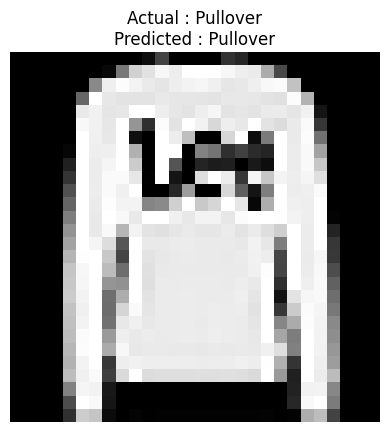

In [ ]:
fashion_labels = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

prediction = model.predict(test_images)

predicted_label = np.argmax(prediction[1])

plt.imshow(test_images[1].reshape(28,28), cmap='gray')
plt.title(f"Actual : {fashion_labels[test_labels[1]]}\nPredicted : {fashion_labels[predicted_label]}")
plt.axis('off')
plt.show()

In [ ]:
print("accuracy:",acc*100)
print("loss",loss)

NameError: name 'acc' is not defined

In [ ]:
from skimage import io, color, transform
import matplotlib.pyplot as plt
import numpy as np


img = io.imread("shirt.png")      # Change filename

# If image has 4 channels (RGBA)
if len(img.shape) == 3 and img.shape[2] == 4:
    img = color.rgba2rgb(img)

# Convert RGB to Grayscale
if len(img.shape) == 3:
    img = color.rgb2gray(img)

# Resize to 28x28
img = transform.resize(img, (28,28))

# Normalize (keep grayscale)
img = img.astype("float32")

# Invert only if your drawing is black on white background
img = 1 - img

# Display grayscale image
plt.imshow(img, cmap='gray')
plt.title("Processed Fashion Image")
plt.axis("off")
plt.show()

# Reshape
img = img.reshape(1,28,28,1)

# Predict
prediction = model.predict(img)

predicted_class = np.argmax(prediction)

fashion_labels = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print("Predicted Class:", fashion_labels[predicted_class])


In [ ]:
prediction = model.predict(test_images[10:19])
predicted_class = np.argmax(prediction)
print(predicted_class)


In [ ]:
prediction = model.predict(test_images)
index = 100

plt.imshow(test_images[index].reshape(28,28), cmap='gray')
plt.show()

predicted = np.argmax(prediction[index])
print(predicted)
predicted_class = ["T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]
print(predicted_class[predicted])